In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import pandas as pd
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "datathon_image_phase_B"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

def format_billions(x, pos):
    return f"{x/1e9:.1f}B"

def format_millions(x, pos):
    return f"{x/1e6:.1f}M"


## Chúng ta đã quan sát toàn bộ dữ liệu và bây giờ sẽ bắt đầu phân tích sâu hơn

### Vì sao doanh thu giảm sau 2018 trong khi AOV vẫn tăng?

### Đọc dữ liệu

In [2]:
sales = pd.read_csv("dataset/sales.csv")
orders = pd.read_csv("dataset/orders.csv")
order_items = pd.read_csv("dataset/order_items.csv")
products = pd.read_csv("dataset/products.csv")
promotions = pd.read_csv("dataset/promotions.csv")
web_traffic = pd.read_csv("dataset/web_traffic.csv")
returns = pd.read_csv("dataset/returns.csv")
shipments = pd.read_csv("dataset/shipments.csv")

# Chuẩn hóa thành dạng ngày tháng
sales["Date"] = pd.to_datetime(sales["Date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
web_traffic["date"] = pd.to_datetime(web_traffic["date"])
returns["return_date"] = pd.to_datetime(returns["return_date"])
shipments["ship_date"] = pd.to_datetime(shipments["ship_date"])
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"])

order_items["line_revenue"] = order_items["quantity"] * order_items["unit_price"]
order_items["gross_revenue"] = order_items["line_revenue"] + order_items["discount_amount"].fillna(0)
order_items["is_promo"] = (
    order_items["promo_id"].notna() | order_items["promo_id_2"].notna()
).astype(int)

order_detail = (
    order_items
    .merge(products, on="product_id", how="left")
    .merge(
        orders[[
            "order_id", "order_date", "customer_id", "zip",
            "order_status", "payment_method", "device_type", "order_source"
        ]],
        on="order_id",
        how="left"
    )
)

order_detail["year_month"] = order_detail["order_date"].dt.to_period("M").dt.to_timestamp()

C:\Users\Admin\AppData\Local\Temp\ipykernel_30644\3529730374.py:3: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("dataset/order_items.csv")


Từ Phase A, vấn đề chính là order count giảm sau 2018. Chúng ta sẽ kiểm tra xem order giảm vì:

+ traffic giảm,
+ conversion giảm,
+ hay AOV thay đổi.

Saving figure b1_funnel_index


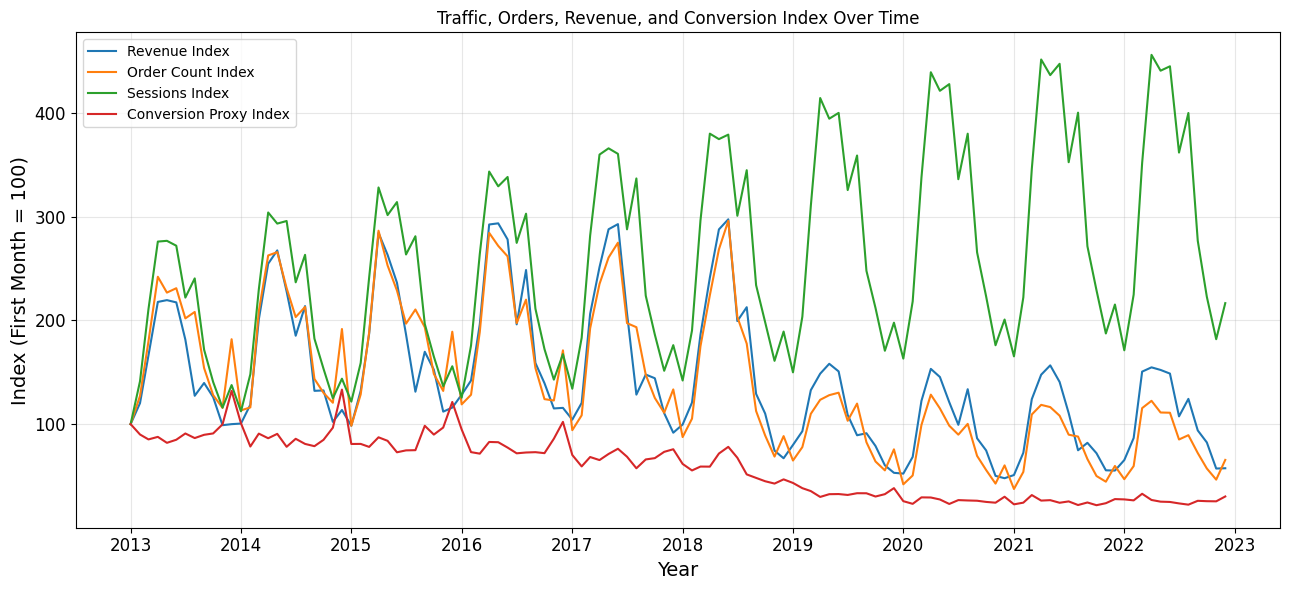

In [3]:
# Daily orders/revenue
daily_orders = (
    order_detail
    .groupby("order_date", as_index=False)
    .agg(
        revenue=("line_revenue", "sum"),
        order_count=("order_id", "nunique")
    )
    .rename(columns={"order_date": "date"})
)

# Daily web traffic
daily_traffic = (
    web_traffic
    .groupby("date", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        bounce_rate=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean")
    )
)

funnel_daily = daily_orders.merge(daily_traffic, on="date", how="inner")
funnel_daily["year_month"] = funnel_daily["date"].dt.to_period("M").dt.to_timestamp()

funnel_monthly = (
    funnel_daily
    .groupby("year_month", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        order_count=("order_count", "sum"),
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum")
    )
)

funnel_monthly["AOV"] = funnel_monthly["revenue"] / funnel_monthly["order_count"]
funnel_monthly["conversion_proxy"] = funnel_monthly["order_count"] / funnel_monthly["sessions"]

# Index all metrics to first available month = 100
indexed = funnel_monthly.copy()
for col in ["revenue", "order_count", "sessions", "conversion_proxy", "AOV"]:
    indexed[col + "_idx"] = indexed[col] / indexed[col].iloc[0] * 100

plt.figure(figsize=(13, 6))
plt.plot(indexed["year_month"], indexed["revenue_idx"], label="Revenue Index")
plt.plot(indexed["year_month"], indexed["order_count_idx"], label="Order Count Index")
plt.plot(indexed["year_month"], indexed["sessions_idx"], label="Sessions Index")
plt.plot(indexed["year_month"], indexed["conversion_proxy_idx"], label="Conversion Proxy Index")

plt.title("Traffic, Orders, Revenue, and Conversion Index Over Time")
plt.xlabel("Year")
plt.ylabel("Index (First Month = 100)")
plt.legend()
plt.grid(alpha=0.3)

plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
save_fig("b1_funnel_index")
plt.show()

Saving figure b1_conversion_proxy


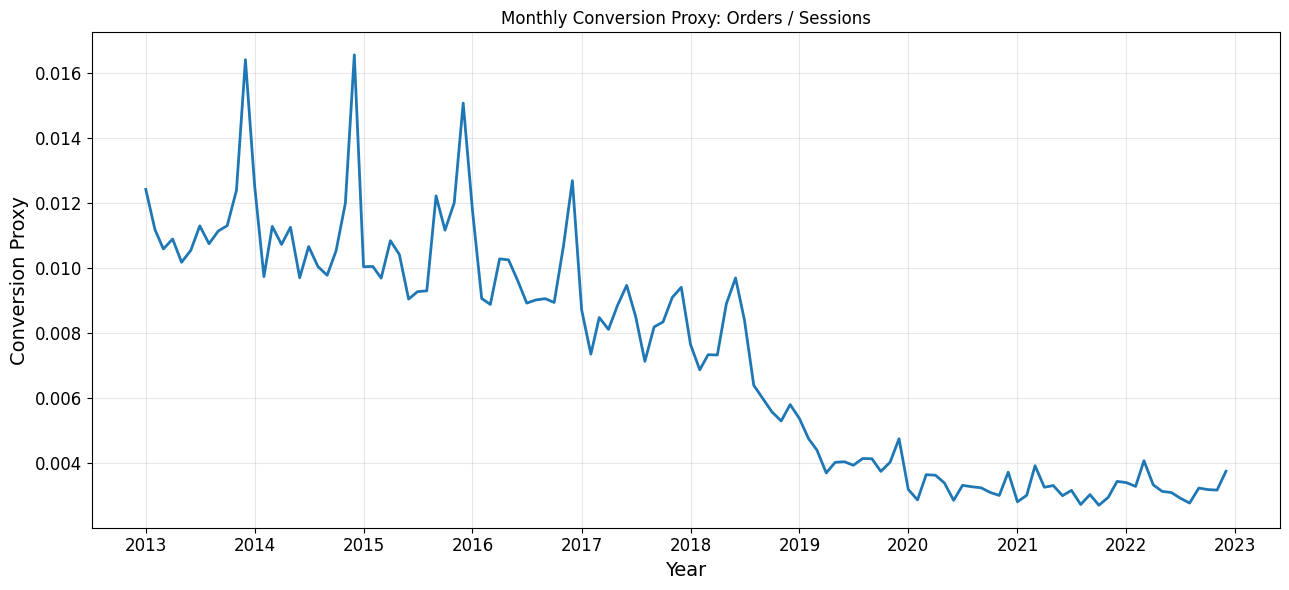

In [4]:
plt.figure(figsize=(13, 6))
plt.plot(funnel_monthly["year_month"], funnel_monthly["conversion_proxy"], linewidth=2)

plt.title("Monthly Conversion Proxy: Orders / Sessions")
plt.xlabel("Year")
plt.ylabel("Conversion Proxy")

plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
save_fig("b1_conversion_proxy")
plt.show()

Promo có thể làm revenue tăng ngắn hạn, nhưng cần xem nó có thật sự tạo healthy demand không.

Câu hỏi chính:

+ Ngày có promo có revenue cao hơn không?
+ Promo làm tăng order count hay chỉ tăng discount?
+ Promo có kéo AOV xuống không?
+ Promo có tạo nhiều return/refund hơn không?

Saving figure b2_revenue_vs_promo_share


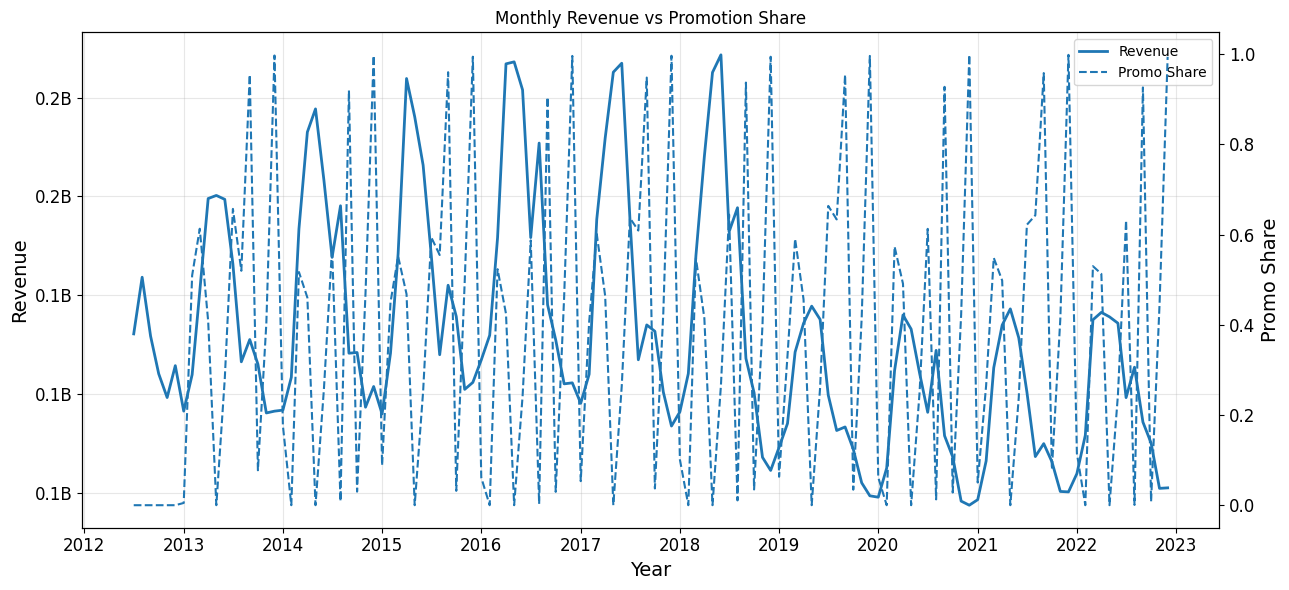

In [10]:
promo_monthly = (
    order_detail
    .groupby("year_month", as_index=False)
    .agg(
        revenue=("line_revenue", "sum"),
        order_count=("order_id", "nunique"),
        promo_lines=("is_promo", "sum"),
        total_lines=("is_promo", "count"),
        discount_amount=("discount_amount", "sum"),
        gross_revenue=("gross_revenue", "sum")
    )
)

promo_monthly["promo_share"] = promo_monthly["promo_lines"] / promo_monthly["total_lines"]
promo_monthly["discount_rate"] = promo_monthly["discount_amount"] / promo_monthly["gross_revenue"]
promo_monthly["AOV"] = promo_monthly["revenue"] / promo_monthly["order_count"]

fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(promo_monthly["year_month"], promo_monthly["revenue"], label="Revenue", linewidth=2)
ax1.set_xlabel("Year")
ax1.set_ylabel("Revenue")
ax1.yaxis.set_major_formatter(FuncFormatter(format_billions))

ax2 = ax1.twinx()
ax2.plot(promo_monthly["year_month"], promo_monthly["promo_share"], label="Promo Share", linestyle="--")
ax2.set_ylabel("Promo Share")

ax1.set_title("Monthly Revenue vs Promotion Share")
ax1.grid(alpha=0.3)

ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.tight_layout()
save_fig("b2_revenue_vs_promo_share")
plt.show()

Saving figure b2_discount_rate_vs_revenue


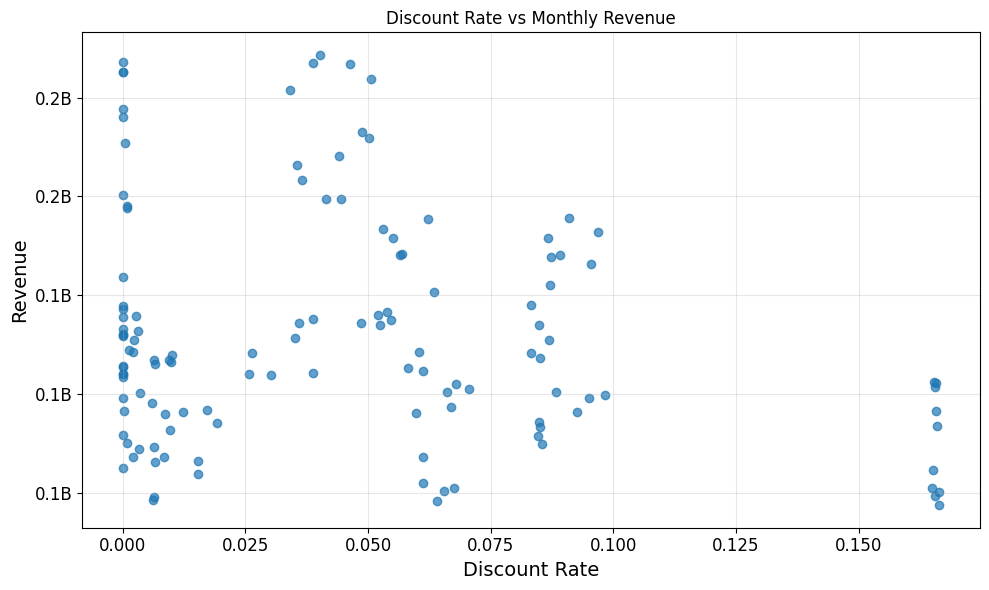

Correlation between discount rate and revenue: -0.20765920246902067


In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(
    promo_monthly["discount_rate"],
    promo_monthly["revenue"],
    alpha=0.7
)

plt.title("Discount Rate vs Monthly Revenue")
plt.xlabel("Discount Rate")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_billions))
plt.grid(alpha=0.3)

plt.tight_layout()
save_fig("b2_discount_rate_vs_revenue")
plt.show()

corr_discount_revenue = promo_monthly["discount_rate"].corr(promo_monthly["revenue"])
print("Correlation between discount rate and revenue:", corr_discount_revenue)

Saving figure b2_category_promo_revenue


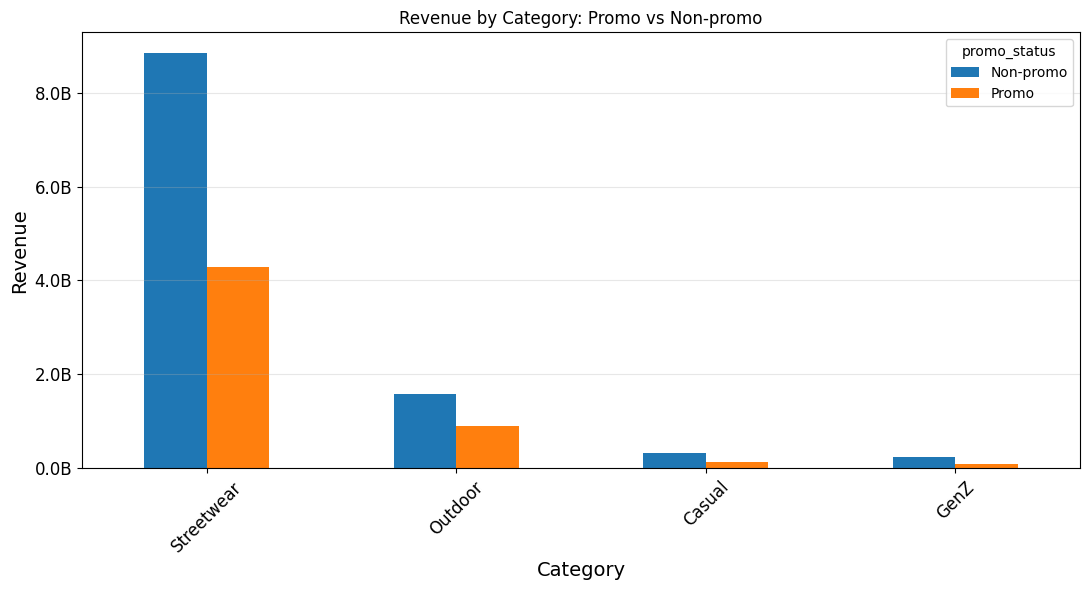

In [12]:
cat_promo = (
    order_detail
    .groupby(["category", "is_promo"], as_index=False)
    .agg(
        revenue=("line_revenue", "sum"),
        order_count=("order_id", "nunique"),
        discount_amount=("discount_amount", "sum"),
        gross_revenue=("gross_revenue", "sum")
    )
)

cat_promo["discount_rate"] = cat_promo["discount_amount"] / cat_promo["gross_revenue"]
cat_promo["promo_status"] = np.where(cat_promo["is_promo"] == 1, "Promo", "Non-promo")

pivot_cat = cat_promo.pivot(index="category", columns="promo_status", values="revenue").fillna(0)
pivot_cat = pivot_cat.sort_values(by=pivot_cat.columns.tolist(), ascending=False)

pivot_cat.plot(kind="bar", figsize=(11, 6))

plt.title("Revenue by Category: Promo vs Non-promo")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_billions))
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("b2_category_promo_revenue")
plt.show()

Promo có tạo demand chất lượng thấp không?

In [13]:
returns_detail = (
    returns
    .merge(products, on="product_id", how="left")
    .merge(
        orders[["order_id", "order_date", "order_source", "device_type", "payment_method"]],
        on="order_id",
        how="left"
    )
)

returns_detail["year_month"] = returns_detail["order_date"].dt.to_period("M").dt.to_timestamp()

# Flag order có return
returned_orders = returns[["order_id"]].drop_duplicates()
returned_orders["has_return"] = 1

order_level = (
    order_detail
    .groupby("order_id", as_index=False)
    .agg(
        order_date=("order_date", "first"),
        revenue=("line_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        is_promo_order=("is_promo", "max"),
        category=("category", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan),
        order_source=("order_source", "first"),
        device_type=("device_type", "first"),
        payment_method=("payment_method", "first")
    )
    .merge(returned_orders, on="order_id", how="left")
)

order_level["has_return"] = order_level["has_return"].fillna(0)
order_level["discount_rate"] = order_level["discount_amount"] / order_level["gross_revenue"]
order_level["year_month"] = order_level["order_date"].dt.to_period("M").dt.to_timestamp()

Saving figure b3_return_rate_promo_vs_nonpromo


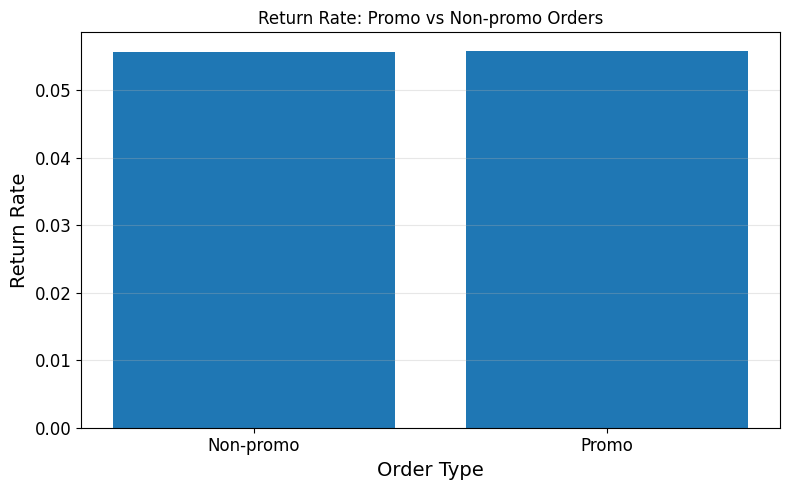

,is_promo_order,orders,returned_orders,avg_revenue,avg_discount_rate,return_rate,promo_status
0,0,398703,22212.0,27565.356894,0.000000,0.055711,Non-promo
1,1,248242,13850.0,21914.446773,0.121506,0.055792,Promo


In [14]:
promo_return = (
    order_level
    .groupby("is_promo_order", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        returned_orders=("has_return", "sum"),
        avg_revenue=("revenue", "mean"),
        avg_discount_rate=("discount_rate", "mean")
    )
)

promo_return["return_rate"] = promo_return["returned_orders"] / promo_return["orders"]
promo_return["promo_status"] = np.where(promo_return["is_promo_order"] == 1, "Promo", "Non-promo")

plt.figure(figsize=(8, 5))
plt.bar(promo_return["promo_status"], promo_return["return_rate"])

plt.title("Return Rate: Promo vs Non-promo Orders")
plt.xlabel("Order Type")
plt.ylabel("Return Rate")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("b3_return_rate_promo_vs_nonpromo")
plt.show()

display(promo_return)

Saving figure b3_category_return_rate_promo


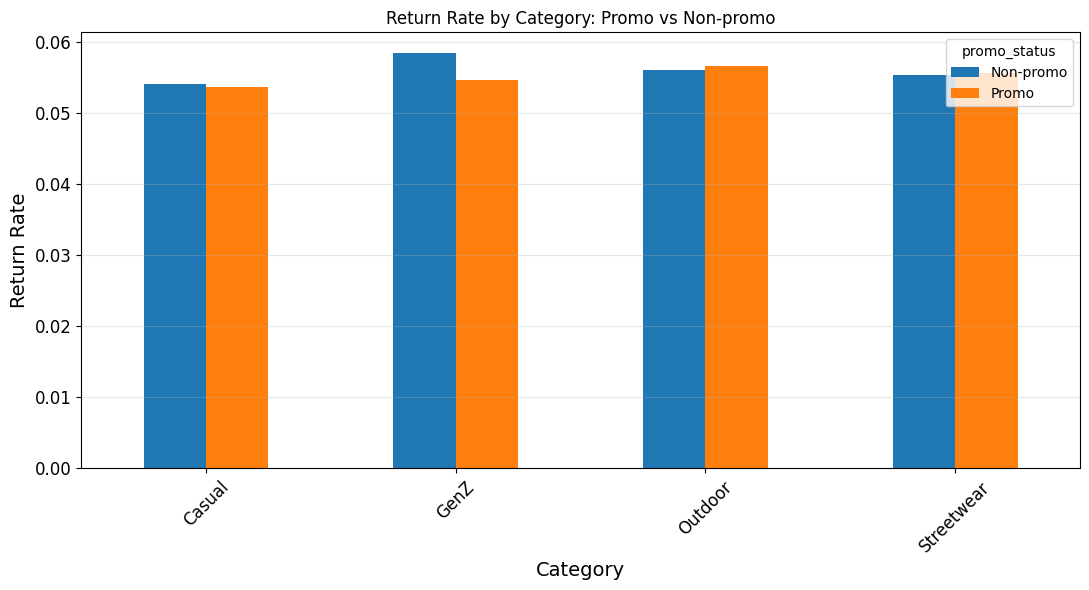

In [15]:
cat_return = (
    order_level
    .groupby(["category", "is_promo_order"], as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        returned_orders=("has_return", "sum")
    )
)

cat_return["return_rate"] = cat_return["returned_orders"] / cat_return["orders"]
cat_return["promo_status"] = np.where(cat_return["is_promo_order"] == 1, "Promo", "Non-promo")

pivot_return = cat_return.pivot(index="category", columns="promo_status", values="return_rate").fillna(0)

pivot_return.plot(kind="bar", figsize=(11, 6))

plt.title("Return Rate by Category: Promo vs Non-promo")
plt.xlabel("Category")
plt.ylabel("Return Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("b3_category_return_rate_promo")
plt.show()

Phase A cho thấy organic_search là nguồn revenue lớn. Nhưng cần hỏi sâu hơn:

+ Organic search nhiều revenue vì nhiều traffic hay conversion tốt?
+ Paid search có traffic cao nhưng conversion thấp không?
+ Social media tạo nhiều sessions nhưng ít orders không?

Saving figure b4_revenue_per_session_by_source


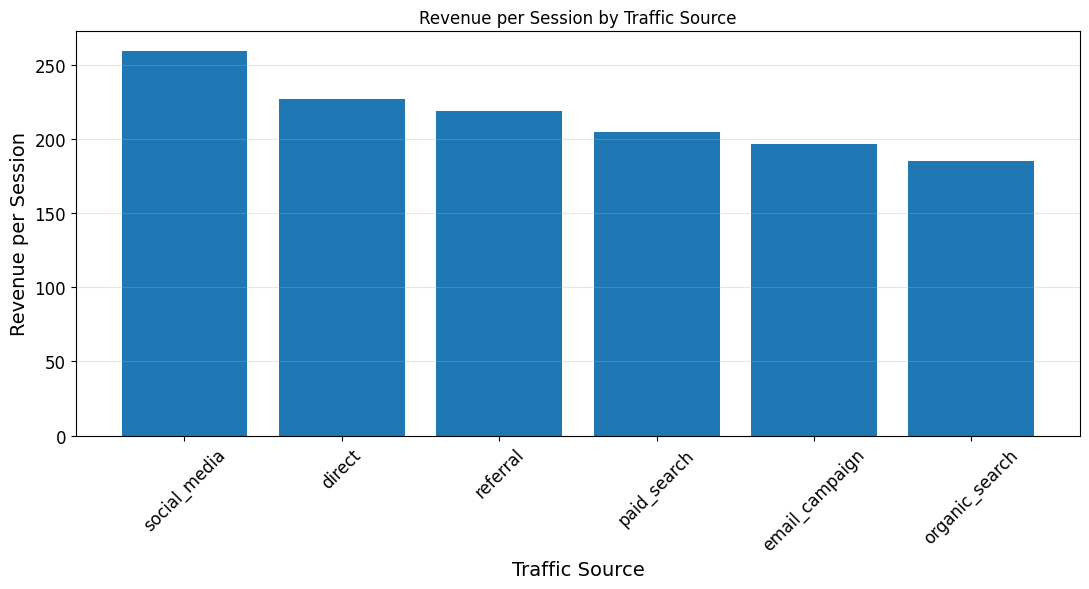

,traffic_source,sessions,revenue,order_count,avg_conversion_proxy,revenue_per_session,avg_bounce_rate
5,social_media,15816226,3.141422e+09,123261,0.010402,259.575658,0.004481
0,direct,6571549,1.100009e+09,42891,0.009018,226.610223,0.004533
4,referral,9476845,1.513128e+09,59052,0.008837,218.781602,0.004480
3,paid_search,19598271,3.441723e+09,134668,0.008210,204.388426,0.004475
1,email_campaign,12792670,1.834473e+09,71524,0.007908,196.669433,0.004453
2,organic_search,27196976,4.387683e+09,172474,0.007394,185.377329,0.004513


In [16]:
# Traffic by month and source
traffic_source_monthly = web_traffic.copy()
traffic_source_monthly["year_month"] = traffic_source_monthly["date"].dt.to_period("M").dt.to_timestamp()

traffic_source_monthly = (
    traffic_source_monthly
    .groupby(["year_month", "traffic_source"], as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        bounce_rate=("bounce_rate", "mean")
    )
)

# Orders/revenue by month and source
order_source_monthly = (
    order_detail
    .groupby(["year_month", "order_source"], as_index=False)
    .agg(
        revenue=("line_revenue", "sum"),
        order_count=("order_id", "nunique")
    )
)

source_funnel = traffic_source_monthly.merge(
    order_source_monthly,
    left_on=["year_month", "traffic_source"],
    right_on=["year_month", "order_source"],
    how="inner"
)

source_funnel["conversion_proxy"] = source_funnel["order_count"] / source_funnel["sessions"]
source_funnel["revenue_per_session"] = source_funnel["revenue"] / source_funnel["sessions"]

source_summary = (
    source_funnel
    .groupby("traffic_source", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        revenue=("revenue", "sum"),
        order_count=("order_count", "sum"),
        avg_conversion_proxy=("conversion_proxy", "mean"),
        revenue_per_session=("revenue_per_session", "mean"),
        avg_bounce_rate=("bounce_rate", "mean")
    )
    .sort_values("revenue_per_session", ascending=False)
)

plt.figure(figsize=(11, 6))
plt.bar(source_summary["traffic_source"], source_summary["revenue_per_session"])

plt.title("Revenue per Session by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Revenue per Session")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("b4_revenue_per_session_by_source")
plt.show()

display(source_summary)

Saving figure b4_bounce_vs_conversion


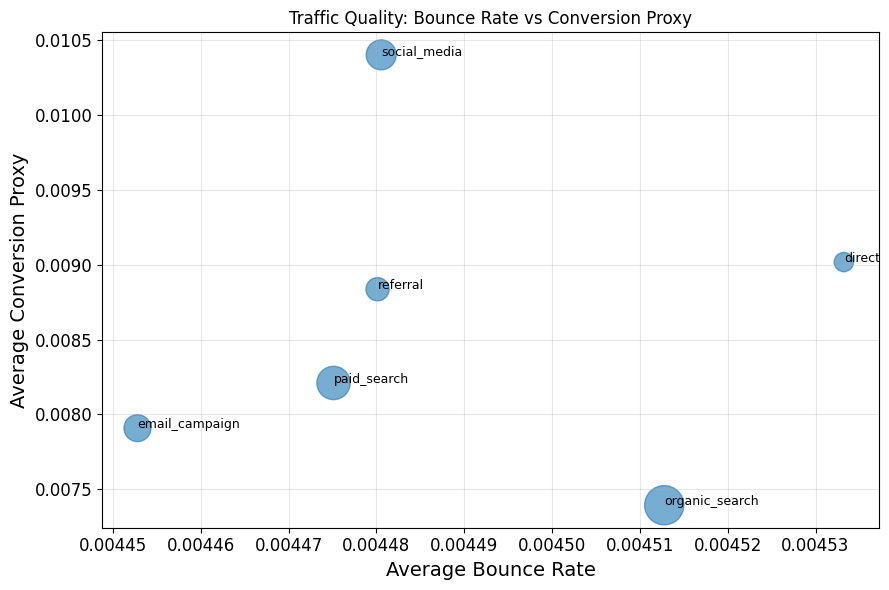

In [17]:
plt.figure(figsize=(9, 6))

plt.scatter(
    source_summary["avg_bounce_rate"],
    source_summary["avg_conversion_proxy"],
    s=source_summary["sessions"] / source_summary["sessions"].max() * 800,
    alpha=0.6
)

for _, row in source_summary.iterrows():
    plt.text(
        row["avg_bounce_rate"],
        row["avg_conversion_proxy"],
        row["traffic_source"],
        fontsize=9
    )

plt.title("Traffic Quality: Bounce Rate vs Conversion Proxy")
plt.xlabel("Average Bounce Rate")
plt.ylabel("Average Conversion Proxy")
plt.grid(alpha=0.3)

plt.tight_layout()
save_fig("b4_bounce_vs_conversion")
plt.show()

Sau 2018, chỉ số nào xấu đi nhiều nhất?

Saving figure b5_driver_changes_after_2018


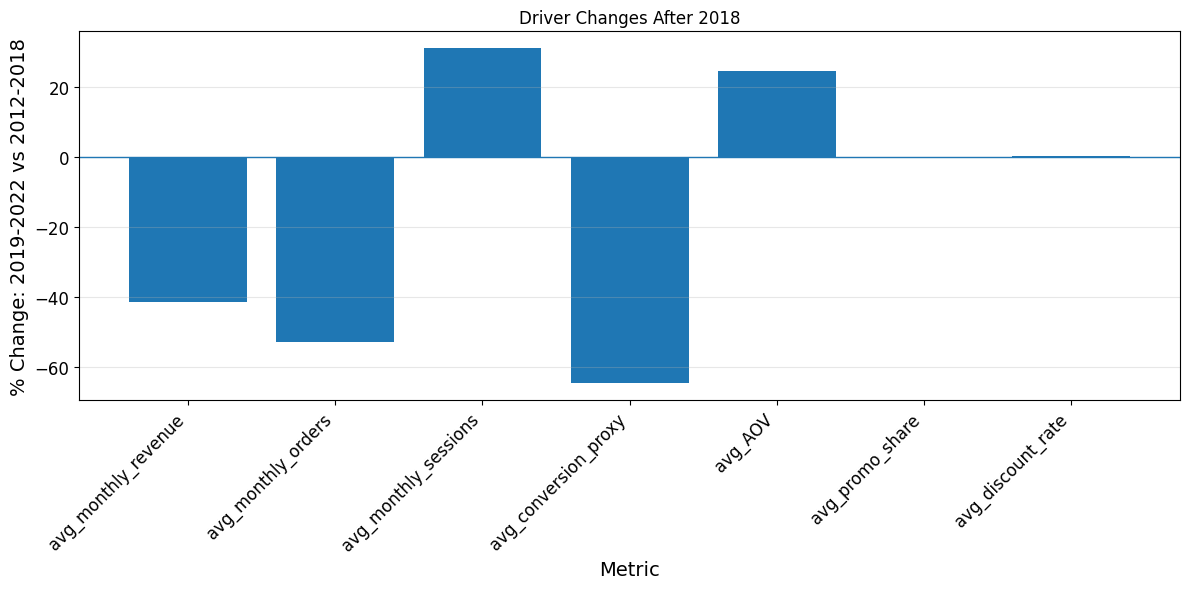

,period,avg_monthly_revenue,avg_monthly_orders,avg_monthly_sessions,avg_conversion_proxy,avg_AOV,avg_promo_share,avg_discount_rate
0,2012-2018,1.567344e+08,6498.375000,677998.944444,0.009852,24189.974105,0.406841,0.048399
1,2019-2022,9.175213e+07,3062.729167,888262.770833,0.003481,30083.515500,0.406164,0.048458


,metric,percent_change
0,avg_monthly_revenue,-41.460119
1,avg_monthly_orders,-52.869307
2,avg_monthly_sessions,31.012412
3,avg_conversion_proxy,-64.669914
4,avg_AOV,24.363571
5,avg_promo_share,-0.166558
6,avg_discount_rate,0.122887


In [18]:
driver_monthly = funnel_monthly.merge(
    promo_monthly[["year_month", "promo_share", "discount_rate"]],
    on="year_month",
    how="left"
)

driver_monthly["period"] = np.where(
    driver_monthly["year_month"].dt.year <= 2018,
    "2012-2018",
    "2019-2022"
)

period_summary = (
    driver_monthly
    .groupby("period", as_index=False)
    .agg(
        avg_monthly_revenue=("revenue", "mean"),
        avg_monthly_orders=("order_count", "mean"),
        avg_monthly_sessions=("sessions", "mean"),
        avg_conversion_proxy=("conversion_proxy", "mean"),
        avg_AOV=("AOV", "mean"),
        avg_promo_share=("promo_share", "mean"),
        avg_discount_rate=("discount_rate", "mean")
    )
)

metrics = [
    "avg_monthly_revenue",
    "avg_monthly_orders",
    "avg_monthly_sessions",
    "avg_conversion_proxy",
    "avg_AOV",
    "avg_promo_share",
    "avg_discount_rate"
]

pre = period_summary[period_summary["period"] == "2012-2018"].iloc[0]
post = period_summary[period_summary["period"] == "2019-2022"].iloc[0]

change_df = pd.DataFrame({
    "metric": metrics,
    "percent_change": [(post[m] - pre[m]) / pre[m] * 100 for m in metrics]
})

plt.figure(figsize=(12, 6))
plt.bar(change_df["metric"], change_df["percent_change"])

plt.axhline(0, linewidth=1)
plt.title("Driver Changes After 2018")
plt.xlabel("Metric")
plt.ylabel("% Change: 2019-2022 vs 2012-2018")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_fig("b5_driver_changes_after_2018")
plt.show()

display(period_summary)
display(change_df)